In [1]:
import sqlite3

import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
CHARTS_DIR = "../assets"

conn = sqlite3.connect("../database.db")

players = pd.read_sql("SELECT * FROM players", conn)
ladder = pd.read_sql("SELECT * FROM ladder_history", conn)
matches = pd.read_sql("SELECT * FROM matches", conn)
players_matches = pd.read_sql("SELECT * FROM players_matches", conn)

conn.close()

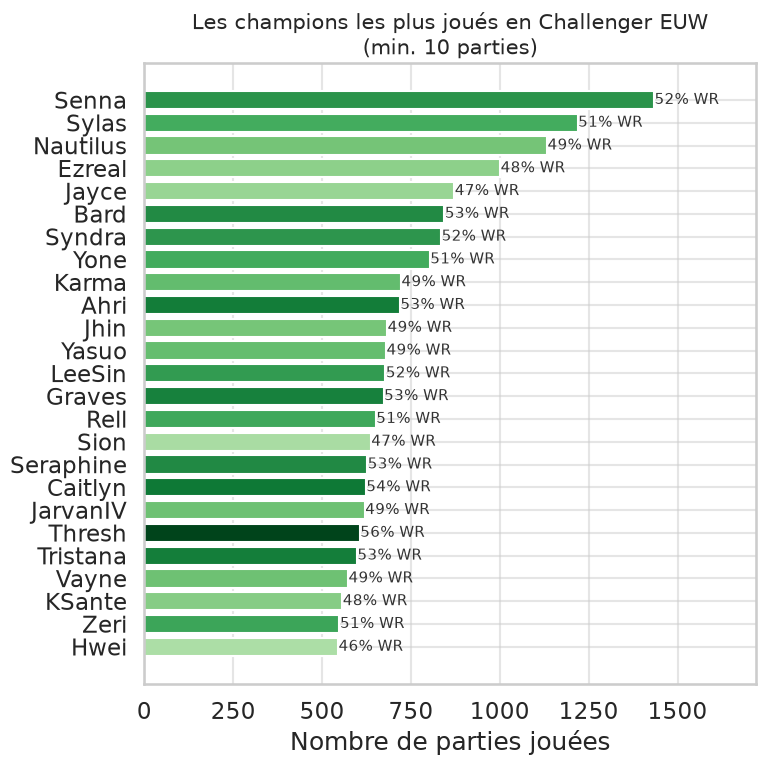

In [2]:
surrender_ids_to_clear = (
    players_matches.groupby("match_id")[["game_surrendered", "game_early_surrender"]]
    .first()
    .reset_index()
    .query("game_surrendered == 1 or game_early_surrender == 1")["match_id"]
)

matches_clean = matches[
    ~(
        ((matches["duration"] < 900) & (matches["id"].isin(surrender_ids_to_clear)))
        | (matches["duration"] <= 600)
    )
]


main_data = players_matches.merge(
    matches, left_on="match_id", right_on="id", suffixes=("", "_match")
)

meta_champs = (
    main_data.groupby("champion_name")
    .agg(
        games=("match_id", "count"),
        winrate=("win", "mean"),
    )
    .query("games >= 10")
    .sort_values("games", ascending=False)
    .head(25)
    .iloc[::-1]
)

norm = mcolors.Normalize(
    vmin=meta_champs["winrate"].min() - 0.05, vmax=meta_champs["winrate"].max()
)
colors = plt.cm.Greens(norm(meta_champs["winrate"]))

fig, ax = plt.subplots(figsize=(8, 8))
bars = ax.barh(meta_champs.index, meta_champs["games"], color=colors)

for bar, wr in zip(bars, meta_champs["winrate"], strict=True):
    ax.text(
        bar.get_width() + 1.5,
        bar.get_y() + bar.get_height() / 2,
        f"{wr * 100:.0f}% WR",
        va="center",
        fontsize=11,
        color="#333",
    )

ax.set_xlabel("Nombre de parties jouées")
ax.set_xlim(0, meta_champs["games"].max() * 1.2)
ax.set_title(
    "Les champions les plus joués en Challenger EUW\n(min. 10 parties)",
    fontsize=15,
)

fig.tight_layout()
plt.savefig(f"{CHARTS_DIR}/champions_popularite_winrate.png")
plt.show()

In [3]:
print(f"Matchs bruts : {len(matches)}")
print(
    f"Matchs après nettoyage : {len(matches_clean)} "
    f"(remakes exclus: {len(matches) - len(matches_clean)})"
)
print(f"Participations exploitables : {len(main_data)}")
print(f"Champions distincts : {main_data['champion_name'].nunique()}")
print(f"Joueurs distincts dans les games : {main_data['player_puuid'].nunique()}")

Matchs bruts : 5569
Matchs après nettoyage : 5483 (remakes exclus: 86)
Participations exploitables : 55690
Champions distincts : 173
Joueurs distincts dans les games : 6023


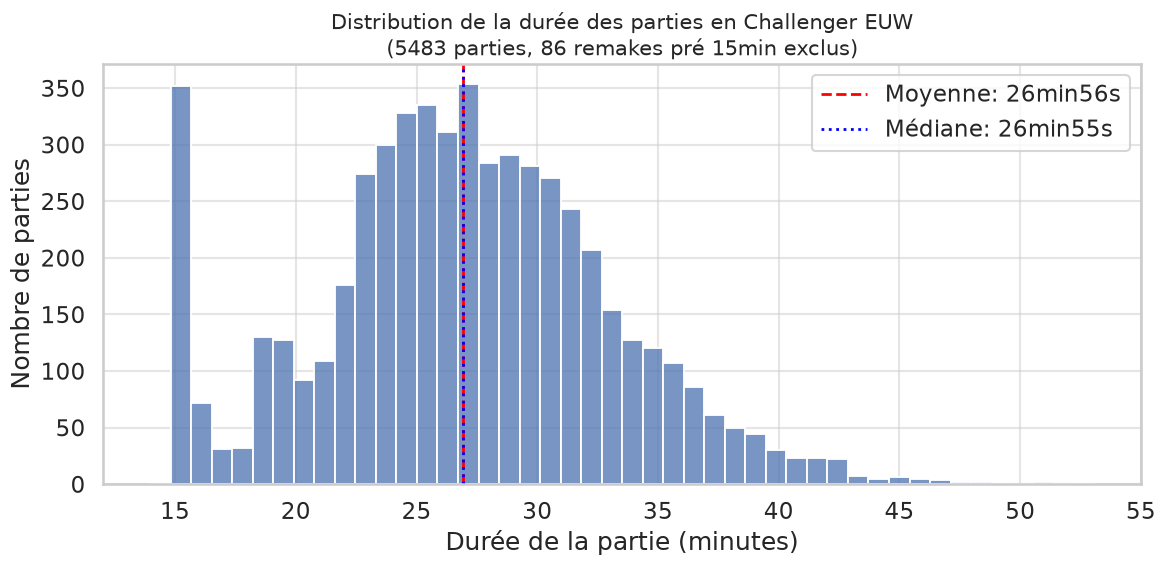

In [4]:
match_durations = matches_clean["duration"] / 60

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(match_durations, edgecolor="white", ax=ax)
mean_d, med_d = match_durations.mean(), match_durations.median()
ax.axvline(
    mean_d,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Moyenne: {int(mean_d)}min{int((mean_d % 2) * 60)}s",
)
ax.axvline(
    med_d,
    color="blue",
    linestyle=":",
    linewidth=2,
    label=f"Médiane: {int(med_d)}min{int((med_d % 2) * 60)}s",
)
ax.set_xlabel("Durée de la partie (minutes)")
ax.set_ylabel("Nombre de parties")
ax.set_title(
    f"Distribution de la durée des parties en Challenger EUW\n"
    f"({len(matches_clean)} parties, {len(matches) - len(matches_clean)} remakes pré 15min exclus)",
    fontsize=15,
)
ax.legend()
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/duree_partie.png")
plt.show()

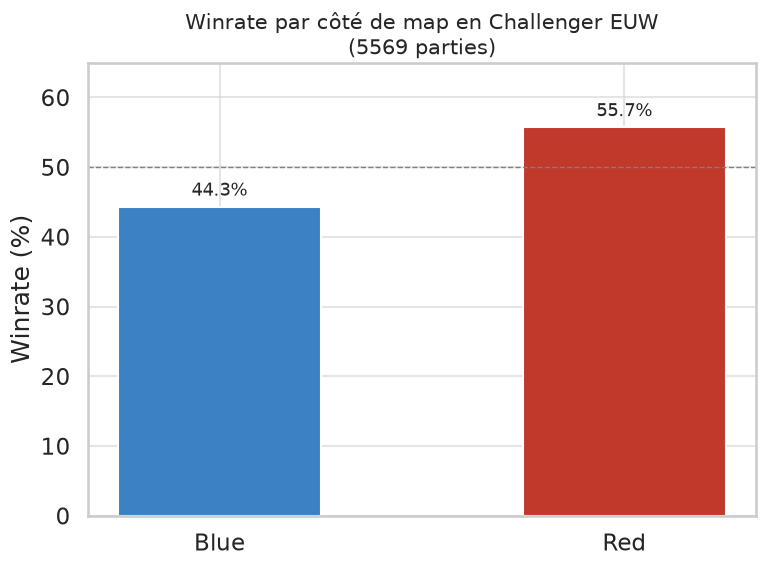

In [5]:
side_stats = main_data.drop_duplicates("match_id").copy()
side_stats["team_win"] = side_stats["team_win"].map({100: "Blue", 200: "Red"})
side_winrate = side_stats["team_win"].value_counts(normalize=True).reindex(["Blue", "Red"])

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(
    side_winrate.index,
    side_winrate.values * 100,
    color=["#3B82C4", "#C0392B"],
    edgecolor="white",
    width=0.5,
)
ax.bar_label(bars, fmt="%.1f%%", padding=5, fontsize=13)
ax.axhline(50, color="gray", linestyle="--", linewidth=1)
ax.set_ylabel("Winrate (%)")
ax.set_ylim(0, 65)
ax.set_title(f"Winrate par côté de map en Challenger EUW\n({len(side_stats)} parties)", fontsize=15)
plt.tight_layout()
plt.show()

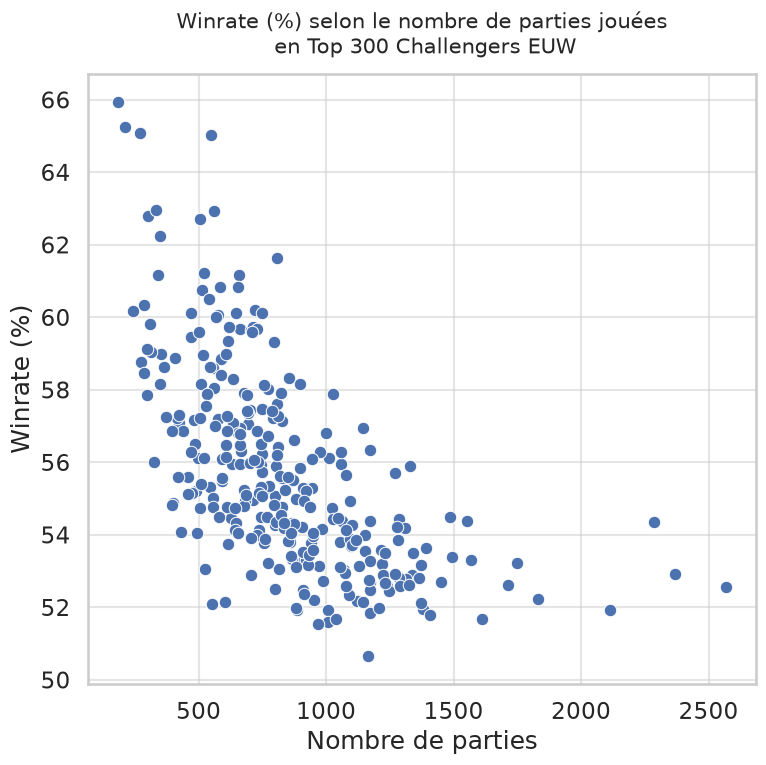

In [6]:
players["in_top"] = players["in_top"].astype(bool)
challengers = players[players["in_top"]]
challengers["games"] = challengers["wins"] + challengers["losses"]
challengers["winrate"] = (challengers["wins"] / challengers["games"]) * 100


fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(data=challengers, x="games", y="winrate", ax=ax)
ax.set_ylabel("Winrate (%)")
ax.set_xlabel("Nombre de parties")

ax.set_title(
    "Winrate (%) selon le nombre de parties jouées\n en Top 300 Challengers EUW",
    fontsize=15,
    y=1.02,
)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/winrate_partie_challs.png")
plt.show()

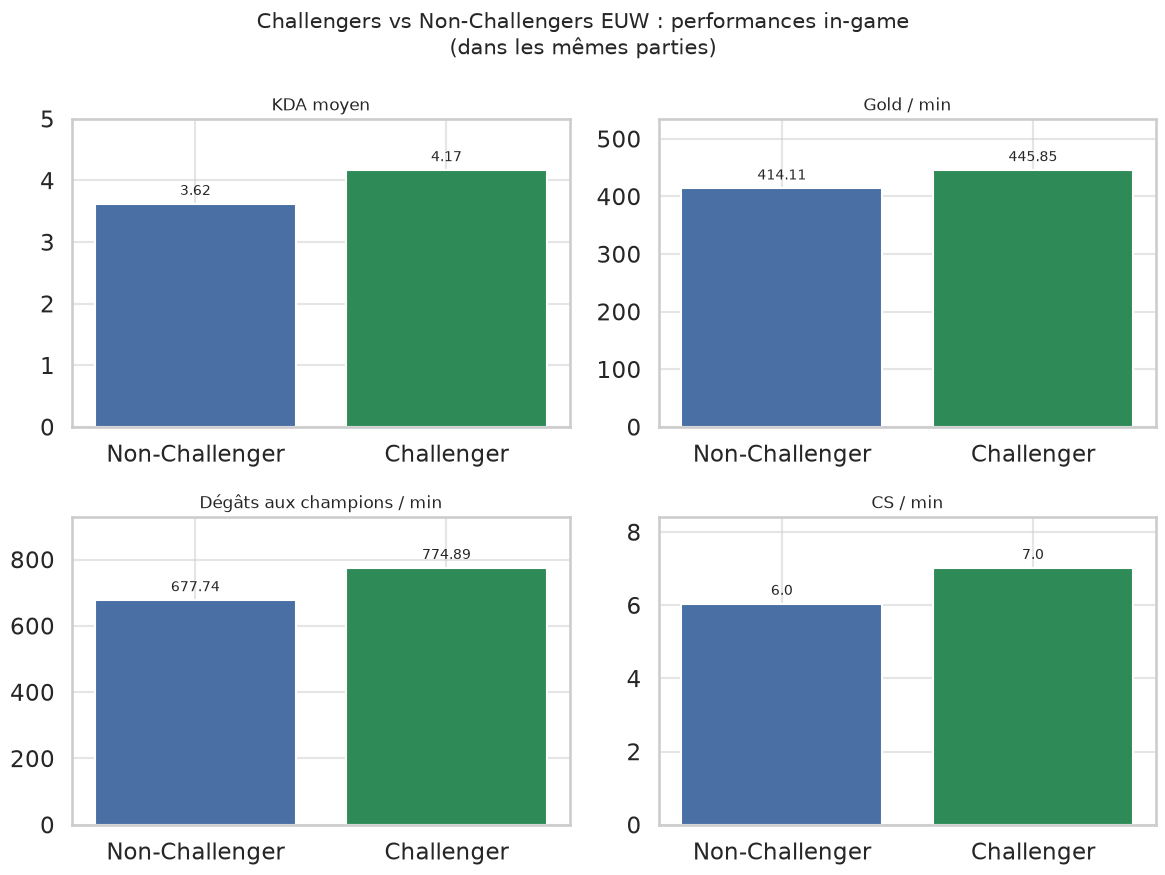

In [7]:
players_matches_tracked = main_data.copy()
players_matches_tracked["is_challenger"] = players_matches_tracked["player_puuid"].isin(
    challengers["puuid"]
)
players_matches_tracked["duration_min"] = players_matches_tracked["duration"] / 60

players_matches_tracked["kda"] = (
    players_matches_tracked["kills"] + players_matches_tracked["assists"]
) / players_matches_tracked["deaths"].replace(0, 1)
players_matches_tracked["gold_per_min"] = (
    players_matches_tracked["gold_earned"] / players_matches_tracked["duration_min"]
)
players_matches_tracked["dmg_per_min"] = (
    players_matches_tracked["total_damage_dealt_to_champions"]
    / players_matches_tracked["duration_min"]
)
players_matches_tracked["cs_per_min"] = (
    players_matches_tracked["total_minions_killed"]
    + players_matches_tracked["neutral_minions_killed"]
) / players_matches_tracked["duration_min"]

group_stats = players_matches_tracked.groupby("is_challenger").agg(
    kda=("kda", "mean"),
    gold_per_min=("gold_per_min", "mean"),
    dmg_per_min=("dmg_per_min", "mean"),
    cs_per_min=("cs_per_min", "mean"),
)

metrics = [
    ("kda", "KDA moyen", "%.2f"),
    ("gold_per_min", "Gold / min", "%.2f"),
    ("dmg_per_min", "Dégâts aux champions / min", "%.2f"),
    ("cs_per_min", "CS / min", "%.1f"),
]

colors = ["#4A6FA5", "#2E8B57"]
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, (col, title, fmt) in zip(axes.flat, metrics, strict=True):
    bars = ax.bar(["Non-Challenger", "Challenger"], group_stats[col], color=colors)
    ax.bar_label(bars, fmt=fmt, padding=4, fontsize=10)
    ax.set_title(title, fontsize=12)
    ax.set_ylim(0, group_stats[col].max() * 1.2)

fig.suptitle(
    "Challengers vs Non-Challengers EUW : performances in-game\n(dans les mêmes parties)",
    fontsize=15,
)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/challs_vs_no-challs_perf.png")
plt.show()

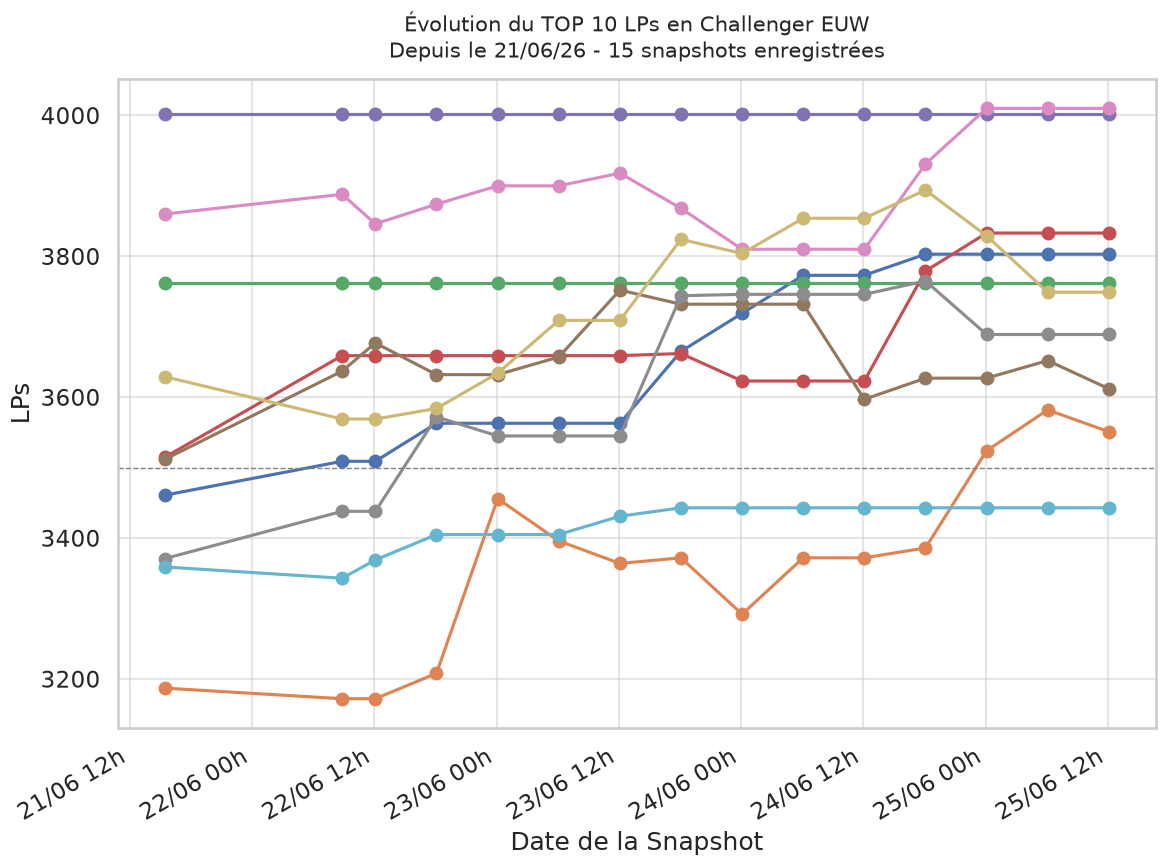

In [8]:
ladder_player = ladder.merge(
    players, left_on="player_puuid", right_on="puuid", suffixes=("", "_player")
)
ladder_player["snapshot_at"] = pd.to_datetime(ladder_player["snapshot_at"], unit="s")


top10_players = (
    ladder_player.sort_values("snapshot_at")
    .groupby("puuid")
    .last()
    .nlargest(10, "league_points")
    .index
)

snapshot_count = len(ladder_player["snapshot_at"].unique())
grouped_players = ladder_player[ladder_player["puuid"].isin(top10_players)].groupby("puuid")

fig, ax = plt.subplots(figsize=(12, 9))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %Hh"))
for _puuid, player_data in grouped_players:
    ax.plot(player_data["snapshot_at"], player_data["league_points"], "o-")

ax.axhline(3500, color="gray", linestyle="--", linewidth=1)

ax.set_ylabel("LPs")
ax.set_xlabel("Date de la Snapshot")
ax.set_title(
    f"Évolution du TOP 10 LPs en Challenger EUW\n"
    f"Depuis le 21/06/26 - {snapshot_count} snapshots enregistrées",
    fontsize=15,
    y=1.02,
)

fig.autofmt_xdate()
fig.tight_layout()
plt.savefig(f"{CHARTS_DIR}/top10_lps.png")
plt.show()

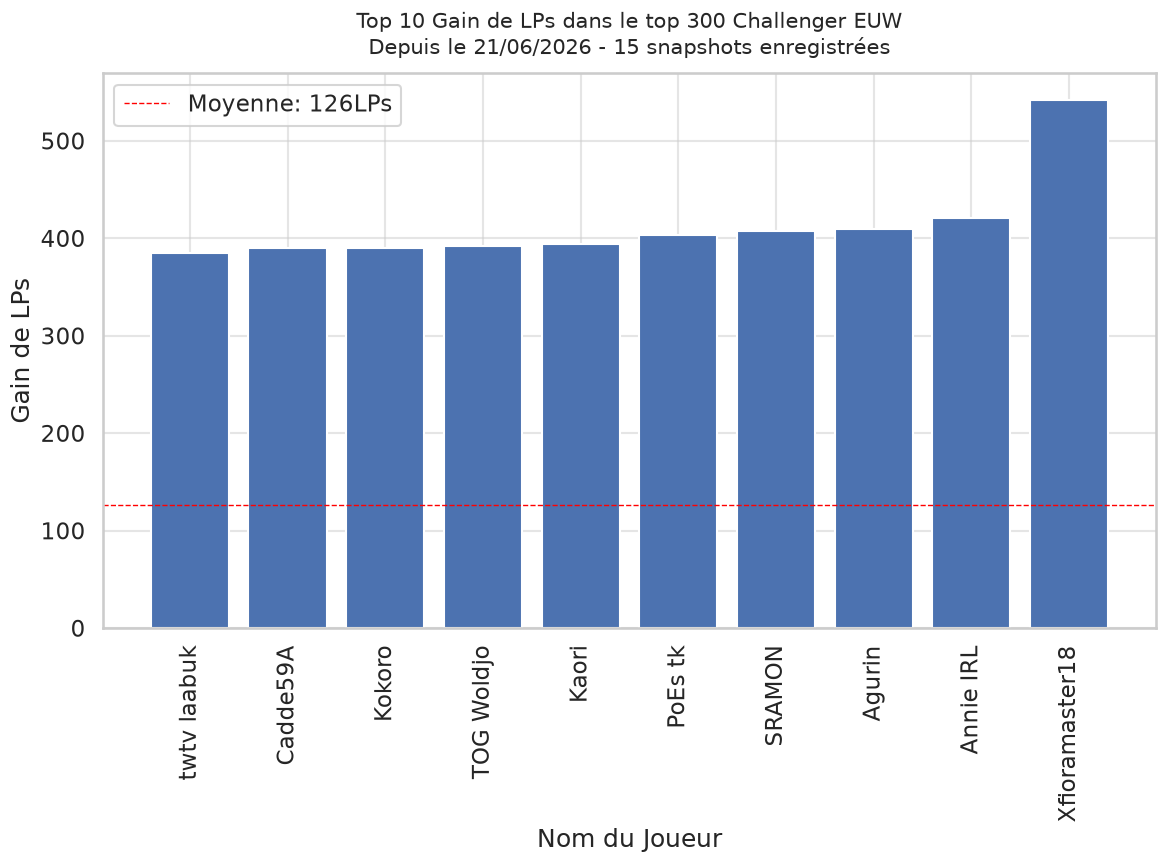

In [9]:
players_snapshots = (
    ladder_player.sort_values("snapshot_at")
    .groupby("puuid")
    .agg(
        first_wins=("wins", "first"),
        first_losses=("losses", "first"),
        first_lps=("league_points", "min"),
        last_wins=("wins", "last"),
        last_losses=("losses", "last"),
        last_lps=("league_points", "max"),
        game_name=("game_name", "last"),
        tagline=("tagline", "last"),
    )
)


players_snapshots["delta"] = players_snapshots["last_lps"] - players_snapshots["first_lps"]
players_snapshots["games_count"] = (
    players_snapshots["last_wins"] + players_snapshots["last_losses"]
) - (players_snapshots["first_wins"] + players_snapshots["first_losses"])
players_snapshots_data = (
    players_snapshots.sort_values("delta", ascending=False).head(10).reset_index().iloc[::-1]
)

mean_lps = players_snapshots["delta"].mean()

fig, ax = plt.subplots(figsize=(12, 9))
ax.bar(x=players_snapshots_data["game_name"], height=players_snapshots_data["delta"])
ax.axhline(mean_lps, color="red", linestyle="--", linewidth=1, label=f"Moyenne: {int(mean_lps)}LPs")
ax.set_xlabel("Nom du Joueur")
ax.set_ylabel("Gain de LPs")
ax.tick_params(axis="x", rotation=90)
ax.set_title(
    f"Top 10 Gain de LPs dans le top 300 Challenger EUW\n"
    f"Depuis le 21/06/2026 - {snapshot_count} snapshots enregistrées",
    fontsize=15,
    y=1.02,
)
ax.legend()
fig.align_xlabels()
fig.tight_layout()
plt.savefig(f"{CHARTS_DIR}/top10_gain_lps.png")
plt.show()